In [39]:
import pandas as pd


In [38]:
df=pd.read_csv(r"C:\Users\hp\Downloads\online_furniture_retailer (1).csv")
df.head()

,product_category,product_subcategory,brand,delivery_status,assembly_service_requested,payment_method,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating,NSP_Category
0,Outdoor,Patio Set,World Market,Failed Delivery,True,Credit Card,93810,2824,191.27,45.63,86.82,323.72,11,3.2,Detractor
1,Living Room,Sofa,West Elm,Cancelled,True,Apple Pay,13278,5506,702.87,52.65,183.07,938.59,10,4.5,Promoter
2,Dining Room,Bar Stool,Ashley Furniture,Delivered,False,Cash on Delivery,42098,4657,395.41,96.79,0.00,492.20,2,NaN,Detractor
3,Dining Room,China Cabinet,HomeGoods,Pending,False,Google Pay,28289,2679,602.59,0.00,0.00,602.59,9,NaN,Detractor
4,Dining Room,China Cabinet,CB2,Pending,True,Apple Pay,98696,9935,1782.36,69.23,41.53,1893.12,13,1.3,Detractor


In [40]:
# add new nsp_category column
def nps_category(score):
    if score >= 4.5:
        return "Promoter"
    elif score >= 3.5:
        return "Passive"
    else:
        return "Detractor"

df["nps_category"] =df["customer_rating"].apply(nps_category)
df.head()
df.tail()


,product_category,product_subcategory,brand,delivery_status,assembly_service_requested,payment_method,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating,NSP_Category,nps_category
1933,Bedroom,Chest of Drawers,Overstock,Delivered,False,PayPal,84537,1474,2020.28,95.02,0.00,2115.30,9,2.9,Detractor,Detractor
1934,Dining Room,Dining Chair,Pottery Barn,In Transit,True,Cash on Delivery,32772,4158,929.03,0.00,91.56,1020.59,9,4.4,Passive,Passive
1935,Office,Desk,Ashley Furniture,Pending,True,Cash on Delivery,36309,1944,726.73,0.00,58.77,785.50,11,NaN,Detractor,Detractor
1936,Living Room,Armchair,Wayfair,In Transit,True,Google Pay,42701,1541,2109.30,NaN,NaN,2374.30,3,NaN,Detractor,Detractor
1937,Kitchen,Kitchen Cabinet,West Elm,Pending,False,Cash on Delivery,69827,1828,550.84,0.00,0.00,550.84,10,1.1,Detractor,Detractor


In [5]:
df.describe()

,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating
count,1938.000000,1938.000000,1938.000000,1880.000000,1900.000000,1938.000000,1938.000000,1658.000000
mean,55199.490712,5592.021672,1155.930026,69.622250,62.698137,1288.390010,7.528380,3.059047
std,25852.427404,2611.344607,658.490908,47.555003,82.552601,669.228652,3.987004,1.152078
min,10053.000000,1009.000000,81.430000,0.000000,0.000000,146.930000,1.000000,1.000000
25%,32218.750000,3290.000000,609.242500,32.585000,0.000000,722.707500,4.000000,2.100000
50%,54741.000000,5703.000000,1076.230000,74.055000,26.285000,1224.175000,8.000000,3.100000
75%,77773.500000,7867.250000,1628.550000,107.735000,106.115000,1758.500000,11.000000,4.000000
max,99952.000000,9998.000000,2979.560000,150.000000,299.350000,3093.290000,14.000000,5.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1938 entries, 0 to 1937
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_category            1938 non-null   object 
 1   product_subcategory         1938 non-null   object 
 2   brand                       1842 non-null   object 
 3   delivery_status             1938 non-null   object 
 4   assembly_service_requested  1938 non-null   bool   
 5   payment_method              1938 non-null   object 
 6   order_id                    1938 non-null   int64  
 7   customer_id                 1938 non-null   int64  
 8   product_price               1938 non-null   float64
 9   shipping_cost               1880 non-null   float64
 10  assembly_cost               1900 non-null   float64
 11  total_amount                1938 non-null   float64
 12  delivery_window_days        1938 non-null   int64  
 13  customer_rating             1658 

In [7]:
#Remove the duplicates and count the NaN values in each columns
df.drop_duplicates()
df.isna().sum()

product_category                0
product_subcategory             0
brand                          96
delivery_status                 0
assembly_service_requested      0
payment_method                  0
order_id                        0
customer_id                     0
product_price                   0
shipping_cost                  58
assembly_cost                  38
total_amount                    0
delivery_window_days            0
customer_rating               280
NSP_Category                    0
nps_category                    0
dtype: int64

In [8]:
# Total row in dataset
len(df)

1938

<Axes: >

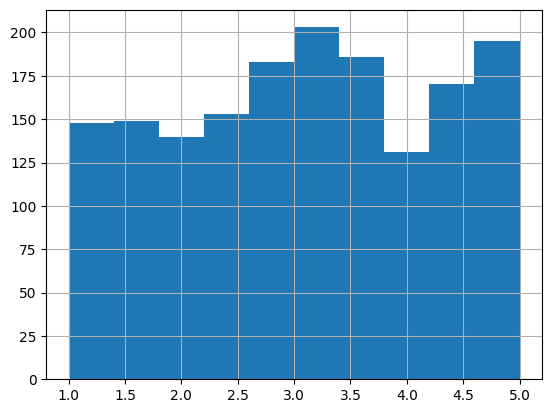

In [9]:
df['customer_rating'].hist()

In [42]:
Q1 = df['customer_rating'].quantile(0.25)
Q3 = df['customer_rating'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['customer_rating'] < lower_bound) | (df['customer_rating'] > upper_bound)]
outliers.head()


,product_category,product_subcategory,brand,delivery_status,assembly_service_requested,payment_method,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating,NSP_Category,nps_category


In [10]:
df['customer_rating'].describe()

count    1658.000000
mean        3.059047
std         1.152078
min         1.000000
25%         2.100000
50%         3.100000
75%         4.000000
max         5.000000
Name: customer_rating, dtype: float64

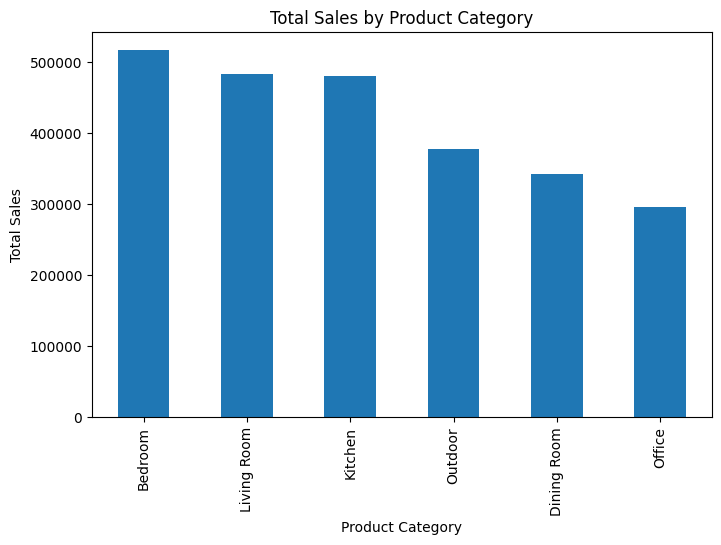

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Group sales by product category
sales_by_category = df.groupby('product_category')['total_amount'].sum().sort_values(ascending=False)

# Plot
sales_by_category.plot(kind='bar', figsize=(8,5))
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.show()


In [45]:
rating_by_status = df.groupby('delivery_status')['customer_rating'].mean()
rating_by_status


delivery_status
Cancelled          3.133579
Delivered          3.142905
Failed Delivery    2.985357
In Transit         2.980505
Pending            3.027778
Rescheduled        3.081061
Name: customer_rating, dtype: float64

In [46]:
# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Correlation matrix
corr_matrix = numeric_df.corr()
corr_matrix


,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating
order_id,1.000000,0.020766,0.015435,-0.025683,0.008576,0.013983,-0.033441,0.035997
customer_id,0.020766,1.000000,0.028750,0.002395,0.007671,0.029159,0.018156,0.014676
product_price,0.015435,0.028750,1.000000,0.044991,0.019370,0.989521,0.012339,0.033141
shipping_cost,-0.025683,0.002395,0.044991,1.000000,0.026502,0.119041,-0.009137,-0.038922
assembly_cost,0.008576,0.007671,0.019370,0.026502,1.000000,0.144745,-0.055306,0.054382
total_amount,0.013983,0.029159,0.989521,0.119041,0.144745,1.000000,0.004500,0.036039
delivery_window_days,-0.033441,0.018156,0.012339,-0.009137,-0.055306,0.004500,1.000000,-0.003581
customer_rating,0.035997,0.014676,0.033141,-0.038922,0.054382,0.036039,-0.003581,1.000000


C:\Users\hp\AppData\Local\Temp\ipykernel_18132\2044548027.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_sales = df.groupby('order_segment')['total_amount'].sum()


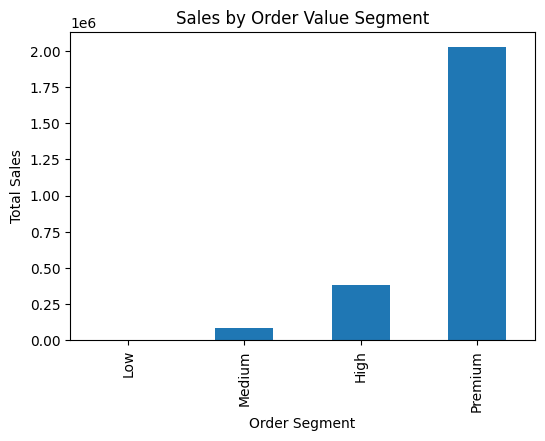

In [48]:
# Create order value segments
df['order_segment'] = pd.cut(df['total_amount'],
                             bins=[0, 200, 500, 1000, 5000],
                             labels=['Low', 'Medium', 'High', 'Premium'])

segment_sales = df.groupby('order_segment')['total_amount'].sum()

segment_sales.plot(kind='bar', figsize=(6,4))
plt.title('Sales by Order Value Segment')
plt.xlabel('Order Segment')
plt.ylabel('Total Sales')
plt.show()


In [11]:
df['nps_category'] = df['customer_rating'].apply(nps_category)
df

,product_category,product_subcategory,brand,delivery_status,assembly_service_requested,payment_method,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating,NSP_Category,nps_category
0,Outdoor,Patio Set,World Market,Failed Delivery,True,Credit Card,93810,2824,191.27,45.63,86.82,323.72,11,3.2,Detractor,Detractor
1,Living Room,Sofa,West Elm,Cancelled,True,Apple Pay,13278,5506,702.87,52.65,183.07,938.59,10,4.5,Promoter,Promoter
2,Dining Room,Bar Stool,Ashley Furniture,Delivered,False,Cash on Delivery,42098,4657,395.41,96.79,0.00,492.20,2,NaN,Detractor,Detractor
3,Dining Room,China Cabinet,HomeGoods,Pending,False,Google Pay,28289,2679,602.59,0.00,0.00,602.59,9,NaN,Detractor,Detractor
4,Dining Room,China Cabinet,CB2,Pending,True,Apple Pay,98696,9935,1782.36,69.23,41.53,1893.12,13,1.3,Detractor,Detractor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1933,Bedroom,Chest of Drawers,Overstock,Delivered,False,PayPal,84537,1474,2020.28,95.02,0.00,2115.30,9,2.9,Detractor,Detractor
1934,Dining Room,Dining Chair,Pottery Barn,In Transit,True,Cash on Delivery,32772,4158,929.03,0.00,91.56,1020.59,9,4.4,Passive,Passive
1935,Office,Desk,Ashley Furniture,Pending,True,Cash on Delivery,36309,1944,726.73,0.00,58.77,785.50,11,NaN,Detractor,Detractor
1936,Living Room,Armchair,Wayfair,In Transit,True,Google Pay,42701,1541,2109.30,NaN,NaN,2374.30,3,NaN,Detractor,Detractor


In [12]:
df.groupby(['delivery_status','assembly_service_requested'])['customer_rating'].mean()

delivery_status  assembly_service_requested
Cancelled        False                         3.103306
                 True                          3.158000
Delivered        False                         3.068493
                 True                          3.215333
Failed Delivery  False                         2.959477
                 True                          3.016535
In Transit       False                         2.938235
                 True                          3.021277
Pending          False                         3.080769
                 True                          2.978571
Rescheduled      False                         2.911111
                 True                          3.236232
Name: customer_rating, dtype: float64

In [13]:
#Sales by product category
df.groupby("product_category")["total_amount"].sum().sort_values(ascending=False)



product_category
Bedroom        516730.84
Living Room    483166.13
Kitchen        480646.75
Outdoor        378300.86
Dining Room    342392.30
Office         295662.96
Name: total_amount, dtype: float64

In [14]:
#df["delivery_status"].value_counts()
df["delivery_status"].value_counts()


delivery_status
Delivered          344
Failed Delivery    326
Pending            319
Cancelled          318
In Transit         316
Rescheduled        315
Name: count, dtype: int64

In [15]:
#Check if assembly increases order value
df.groupby("assembly_service_requested")["total_amount"].mean()


assembly_service_requested
False    1218.881411
True     1356.198094
Name: total_amount, dtype: float64

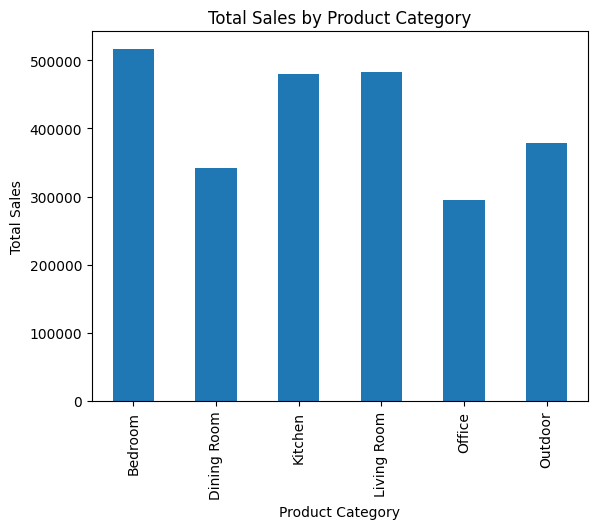

In [16]:
#Bar chart – Sales by product category
import matplotlib.pyplot as plt
df.groupby("product_category")["total_amount"].sum().plot(kind="bar")
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.show()


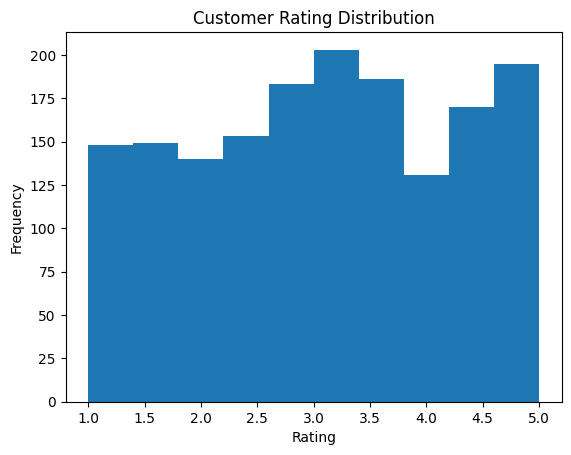

In [17]:
#Histogram – Customer rating
df["customer_rating"].plot(kind="hist")
plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.show()


In [18]:
#Correlation analysis 
df[["product_price", "shipping_cost", "assembly_cost", "total_amount", "delivery_window_days", "customer_rating"]].corr()


,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating
product_price,1.000000,0.044991,0.019370,0.989521,0.012339,0.033141
shipping_cost,0.044991,1.000000,0.026502,0.119041,-0.009137,-0.038922
assembly_cost,0.019370,0.026502,1.000000,0.144745,-0.055306,0.054382
total_amount,0.989521,0.119041,0.144745,1.000000,0.004500,0.036039
delivery_window_days,0.012339,-0.009137,-0.055306,0.004500,1.000000,-0.003581
customer_rating,0.033141,-0.038922,0.054382,0.036039,-0.003581,1.000000


In [19]:
df

,product_category,product_subcategory,brand,delivery_status,assembly_service_requested,payment_method,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating,NSP_Category,nps_category
0,Outdoor,Patio Set,World Market,Failed Delivery,True,Credit Card,93810,2824,191.27,45.63,86.82,323.72,11,3.2,Detractor,Detractor
1,Living Room,Sofa,West Elm,Cancelled,True,Apple Pay,13278,5506,702.87,52.65,183.07,938.59,10,4.5,Promoter,Promoter
2,Dining Room,Bar Stool,Ashley Furniture,Delivered,False,Cash on Delivery,42098,4657,395.41,96.79,0.00,492.20,2,NaN,Detractor,Detractor
3,Dining Room,China Cabinet,HomeGoods,Pending,False,Google Pay,28289,2679,602.59,0.00,0.00,602.59,9,NaN,Detractor,Detractor
4,Dining Room,China Cabinet,CB2,Pending,True,Apple Pay,98696,9935,1782.36,69.23,41.53,1893.12,13,1.3,Detractor,Detractor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1933,Bedroom,Chest of Drawers,Overstock,Delivered,False,PayPal,84537,1474,2020.28,95.02,0.00,2115.30,9,2.9,Detractor,Detractor
1934,Dining Room,Dining Chair,Pottery Barn,In Transit,True,Cash on Delivery,32772,4158,929.03,0.00,91.56,1020.59,9,4.4,Passive,Passive
1935,Office,Desk,Ashley Furniture,Pending,True,Cash on Delivery,36309,1944,726.73,0.00,58.77,785.50,11,NaN,Detractor,Detractor
1936,Living Room,Armchair,Wayfair,In Transit,True,Google Pay,42701,1541,2109.30,NaN,NaN,2374.30,3,NaN,Detractor,Detractor


In [20]:

df['customer_rating'] = df['customer_rating'].astype(float)
df = df.dropna(subset=['customer_rating'])
df
#Business Value:
#Avoids wrong KPIs and misleading insights.

,product_category,product_subcategory,brand,delivery_status,assembly_service_requested,payment_method,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating,NSP_Category,nps_category
0,Outdoor,Patio Set,World Market,Failed Delivery,True,Credit Card,93810,2824,191.27,45.63,86.82,323.72,11,3.2,Detractor,Detractor
1,Living Room,Sofa,West Elm,Cancelled,True,Apple Pay,13278,5506,702.87,52.65,183.07,938.59,10,4.5,Promoter,Promoter
4,Dining Room,China Cabinet,CB2,Pending,True,Apple Pay,98696,9935,1782.36,69.23,41.53,1893.12,13,1.3,Detractor,Detractor
5,Dining Room,Buffet,West Elm,Rescheduled,True,Bank Transfer,21395,7912,1307.80,NaN,170.18,1565.00,11,3.4,Detractor,Detractor
7,Dining Room,Dining Table,Urban Outfitters,Failed Delivery,False,Debit Card,22280,4582,500.87,137.64,0.00,638.51,4,2.6,Detractor,Detractor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1930,Kitchen,Pantry Cabinet,Crate & Barrel,Rescheduled,False,Apple Pay,18600,6097,1888.48,NaN,0.00,1999.22,11,4.2,Passive,Passive
1932,Bedroom,Nightstand,Wayfair,Pending,False,PayPal,27779,9589,720.04,58.38,0.00,778.42,10,2.7,Detractor,Detractor
1933,Bedroom,Chest of Drawers,Overstock,Delivered,False,PayPal,84537,1474,2020.28,95.02,0.00,2115.30,9,2.9,Detractor,Detractor
1934,Dining Room,Dining Chair,Pottery Barn,In Transit,True,Cash on Delivery,32772,4158,929.03,0.00,91.56,1020.59,9,4.4,Passive,Passive


In [21]:
promoters = (df['nps_category'] == 'Promoter').mean() * 100
detractors = (df['nps_category'] == 'Detractor').mean() * 100
nps_score = promoters - detractors


In [22]:
print("Promoters:", promoters)
print("Detractors:", detractors)
print("NPS Score:", nps_score)



Promoters: 14.05307599517491
Detractors: 58.86610373944512
NPS Score: -44.813027744270215


In [23]:
df.groupby('delivery_status')['customer_rating'].mean()


delivery_status
Cancelled          3.133579
Delivered          3.142905
Failed Delivery    2.985357
In Transit         2.980505
Pending            3.027778
Rescheduled        3.081061
Name: customer_rating, dtype: float64

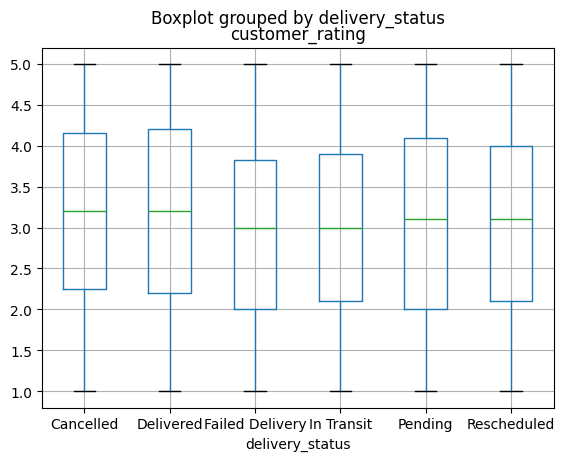

In [24]:
import matplotlib.pyplot as plt

df.boxplot(column='customer_rating', by='delivery_status')
plt.show()


In [25]:
df.groupby('assembly_service_requested')['customer_rating'].describe()


,count,mean,std,min,25%,50%,75%,max
assembly_service_requested,,,,,,,,
False,812.0,3.008867,1.14702,1.0,2.0,3.0,4.0,5.0
True,846.0,3.107210,1.15554,1.0,2.2,3.2,4.1,5.0


In [26]:
df['order_segment'] = df['total_amount'].apply(
    lambda x: 'High Value' if x > 500 else 'Standard'
)
df[df['order_segment'] == 'High Value'].sort_values('customer_rating').head()


C:\Users\hp\AppData\Local\Temp\ipykernel_18132\2106224827.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['order_segment'] = df['total_amount'].apply(


,product_category,product_subcategory,brand,delivery_status,assembly_service_requested,payment_method,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating,NSP_Category,nps_category,order_segment
1782,Office,Filing Cabinet,Crate & Barrel,Rescheduled,False,Credit Card,83807,4084,627.61,92.25,0.00,719.86,14,1.0,Detractor,Detractor,High Value
1860,Outdoor,Outdoor Table,Wayfair,Delivered,True,Debit Card,20739,8758,1376.74,149.88,77.36,1603.98,2,1.0,Detractor,Detractor,High Value
387,Kitchen,Kitchen Island,Urban Outfitters,Cancelled,True,Apple Pay,73464,5530,2231.06,125.24,248.91,2605.21,10,1.0,Detractor,Detractor,High Value
1507,Bedroom,Bed Frame,Ashley Furniture,Rescheduled,True,Debit Card,58085,9880,509.94,137.87,162.41,810.22,1,1.0,Detractor,Detractor,High Value
407,Outdoor,Garden Chair,CB2,Failed Delivery,False,Google Pay,29887,3444,904.37,0.00,0.00,904.37,6,1.0,Detractor,Detractor,High Value


<function matplotlib.pyplot.show(close=None, block=None)>

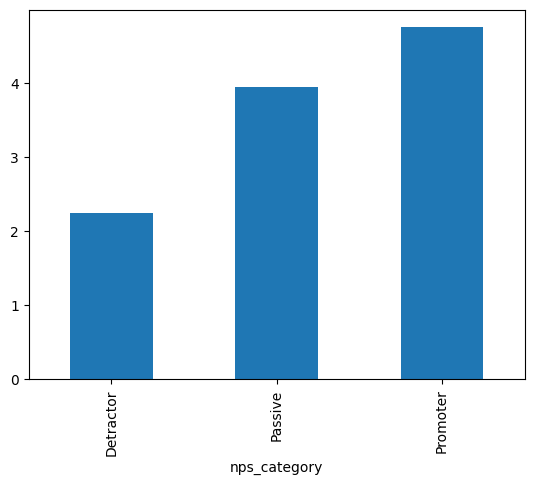

In [27]:
df.groupby('nps_category')['customer_rating'].mean().plot(kind='bar')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

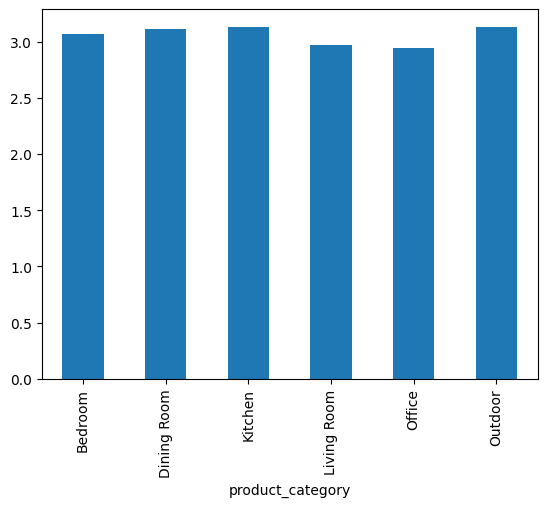

In [28]:
df.groupby('product_category')['customer_rating'].mean().plot(kind='bar')
plt.show


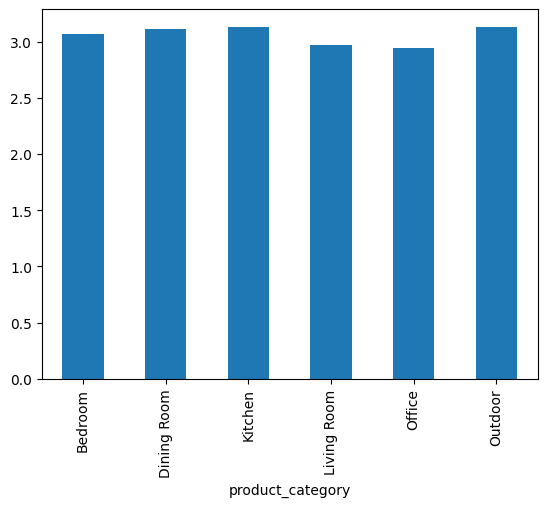

In [29]:
df.groupby('product_category')['customer_rating'].mean().plot(kind='bar')
plt.show()


In [30]:
corr_matrix = df[[
    "product_price",
    "shipping_cost",
    "assembly_cost",
    "total_amount",
    "delivery_window_days",
    "customer_rating"
]].corr()

corr_matrix


,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating
product_price,1.000000,0.052192,0.020160,0.989372,0.014095,0.033141
shipping_cost,0.052192,1.000000,0.035912,0.127281,-0.003843,-0.038922
assembly_cost,0.020160,0.035912,1.000000,0.146778,-0.065904,0.054382
total_amount,0.989372,0.127281,0.146778,1.000000,0.005245,0.036039
delivery_window_days,0.014095,-0.003843,-0.065904,0.005245,1.000000,-0.003581
customer_rating,0.033141,-0.038922,0.054382,0.036039,-0.003581,1.000000


In [31]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


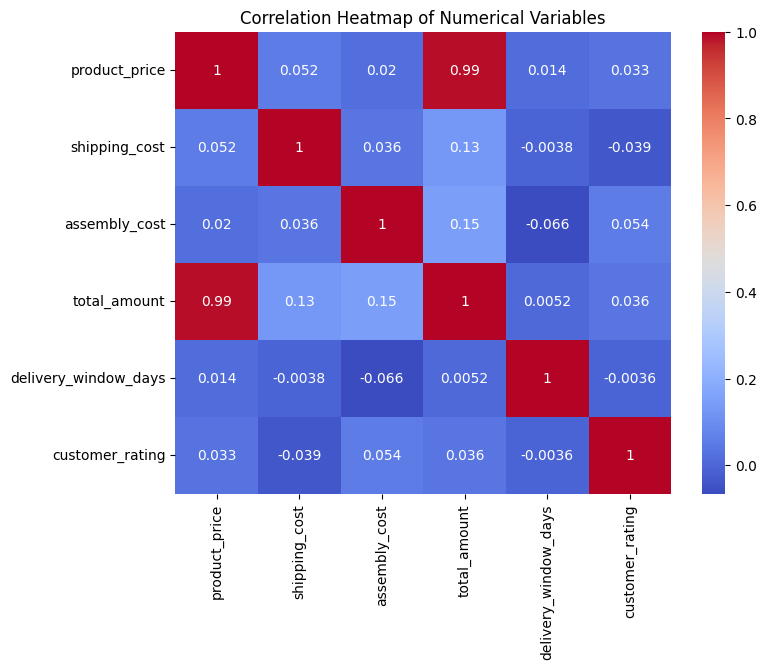

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()


In [33]:
df.shape


(1658, 17)

In [34]:
pip install openpyxl


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
!pip install openpyxl


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import openpyxl
print(openpyxl.__version__)


3.1.5


In [37]:
df.to_excel("Furniture.xlsx", index=False)
